# Exercice 5 (C) - Classification sur le dataset fourni

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import warnings; warnings.filterwarnings('ignore')

X_train = np.load('../data/classification/X_train.npy')
X_test  = np.load('../data/classification/X_test.npy')
y_train = np.load('../data/classification/y_train.npy')
y_test  = np.load('../data/classification/y_test.npy')

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}  y_test:  {y_test.shape}')
print(f'Class balance (train): {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Class balance (test):  {dict(zip(*np.unique(y_test, return_counts=True)))}')
print(f'\nFeature statistics (train):')
print(f'  Mean range: [{X_train.mean(axis=0).min():.3f}, {X_train.mean(axis=0).max():.3f}]')
print(f'  Std  range: [{X_train.std(axis=0).min():.3f}, {X_train.std(axis=0).max():.3f}]')

X_train: (2000, 30)  y_train: (2000,)
X_test:  (2000, 30)  y_test:  (2000,)
Class balance (train): {np.int64(0): np.int64(1019), np.int64(1): np.int64(981)}
Class balance (test):  {np.int64(0): np.int64(1118), np.int64(1): np.int64(882)}

Feature statistics (train):
  Mean range: [-1.004, 0.042]
  Std  range: [0.966, 2.703]


## Analyse du dataset

Le dataset contient 30 features. Notamment, 10 features présentent une variance significativement plus élevée (std > 1,5 avant standardisation) par rapport aux 20 autres features (std ≈ 1). Cela suggère une structure latente où certaines features encodent des interactions non-linéaires.

High-variance features (std > 1.5): [ 4  5  7  8 10 15 17 20 21 23] [10 features]
Low-variance features  (std ≤ 1.5): [0 1 2 3 6]... [20 features]


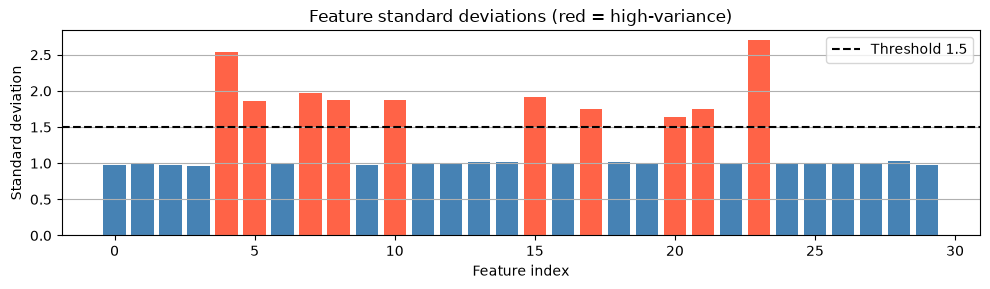

In [2]:
# Feature variance analysis
stds = X_train.std(axis=0)
high_var = np.where(stds > 1.5)[0]
low_var  = np.where(stds <= 1.5)[0]
print(f'High-variance features (std > 1.5): {high_var} [{len(high_var)} features]')
print(f'Low-variance features  (std ≤ 1.5): {low_var[:5]}... [{len(low_var)} features]')

plt.figure(figsize=(10, 3))
plt.bar(range(30), stds, color=['tomato' if s > 1.5 else 'steelblue' for s in stds])
plt.xlabel('Feature index')
plt.ylabel('Standard deviation')
plt.title('Feature standard deviations (red = high-variance)')
plt.axhline(1.5, color='k', ls='--', label='Threshold 1.5')
plt.legend(); plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Prétraitement

On applique `StandardScaler` sur l'ensemble d'entraînement et on applique la même transformation sur l'ensemble de test. Toute la sélection d'hyperparamètres est réalisée par validation croisée stratifiée à 5 plis sur l'ensemble d'entraînement uniquement.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

## Méthode 1 - Régression Logistique

Régression logistique $L_2$ avec force de régularisation $C$ sélectionnée par validation croisée.

In [4]:
param_grid = {'C': np.logspace(-2, 2, 30)}
lr_gs = GridSearchCV(LogisticRegression(max_iter=2000, random_state=42), param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
lr_gs.fit(X_train_s, y_train)

best_lr = lr_gs.best_estimator_
print(f'Logistic Regression - best C : {lr_gs.best_params_["C"]:.4f}')
print(f'Logistic Regression - CV acc : {lr_gs.best_score_:.4f}')

Logistic Regression - best C : 1.6103
Logistic Regression - CV acc : 0.7140


## Méthode 2 - SVM à noyau RBF

SVM avec un noyau RBF (Radial Basis Function) pouvant capturer des frontières de décision non-linéaires. On optimise $C$ (dureté de la marge) et $\gamma$ (largeur du noyau) par CV.

In [5]:
param_grid_svc = {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.01, 0.1]}
svc_gs = GridSearchCV(SVC(kernel='rbf', random_state=42), param_grid_svc, cv=cv, scoring='accuracy', n_jobs=-1)
svc_gs.fit(X_train_s, y_train)

best_svc = svc_gs.best_estimator_
print(f'SVM RBF - best params : {svc_gs.best_params_}')
print(f'SVM RBF - CV acc : {svc_gs.best_score_:.4f}')

SVM RBF - best params : {'C': 10, 'gamma': 0.1}
SVM RBF - CV acc : 0.7735


## Méthode 3 - K Plus Proches Voisins (KNN)

KNN avec $k$ sélectionné par validation croisée. Méthode non-paramétrique qui peut capturer des structures locales complexes dans l'espace des features.

In [6]:
param_grid_knn = {'n_neighbors': [5, 10, 20, 30, 50, 75, 100, 150, 200]}
knn_gs = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=cv, scoring='accuracy', n_jobs=-1)
knn_gs.fit(X_train_s, y_train)

best_knn = knn_gs.best_estimator_
print(f'KNN - best k : {knn_gs.best_params_["n_neighbors"]}')
print(f'KNN - CV acc : {knn_gs.best_score_:.4f}')

KNN - best k : 30
KNN - CV acc : 0.7415


## Méthode 4 - AdaBoost

AdaBoost avec des souches de décision corrige itérativement les erreurs précédentes. On optimise le nombre d'estimateurs et la profondeur de l'estimateur de base.

In [7]:
param_grid_ada = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.5, 1.0],
    'estimator': [DecisionTreeClassifier(max_depth=1), DecisionTreeClassifier(max_depth=2)]
}
ada_gs = GridSearchCV(AdaBoostClassifier(random_state=42), param_grid_ada,
                      cv=cv, scoring='accuracy', n_jobs=-1)
ada_gs.fit(X_train_s, y_train)

best_ada = ada_gs.best_estimator_
print(f'AdaBoost - best params : {ada_gs.best_params_["n_estimators"]} estimators, lr={ada_gs.best_params_["learning_rate"]}, depth={ada_gs.best_params_["estimator"].max_depth}')
print(f'AdaBoost - CV acc : {ada_gs.best_score_:.4f}')

AdaBoost - best params : 300 estimators, lr=0.5, depth=2
AdaBoost - CV acc : 0.7300


## Comparaison

On compare les modèles par leur **précision de validation croisée** (5 plis) sur l'ensemble d'entraînement. L'ensemble de test est utilisé une seule fois pour évaluer le modèle final sélectionné par CV.

In [8]:
results = {
    'Régression Log.': (best_lr,  lr_gs.best_score_),
    'SVM RBF': (best_svc, svc_gs.best_score_),
    'KNN': (best_knn, knn_gs.best_score_),
    'AdaBoost': (best_ada, ada_gs.best_score_),
}

best_name = max(results, key=lambda k: results[k][1])
best_model = results[best_name][0]
best_cv_acc = results[best_name][1]

print(f'{"Modèle":<22} {"Précision CV":>14}')
print('-' * 38)
for name, (_, cv_acc) in results.items():
    marker = ' <- sélectionné' if name == best_name else ''
    print(f'{name:<22} {cv_acc:>14.4f}{marker}')

final_test_acc = best_model.score(X_test_s, y_test)
print(f'\nMeilleur modèle (par CV) : {best_name} (CV = {best_cv_acc:.4f})')
print(f'Précision test (évaluation finale, une seule fois) : {final_test_acc:.4f}')

Modèle                   Précision CV
--------------------------------------
Régression Log.                0.7140
SVM RBF                        0.7735 <- sélectionné
KNN                            0.7415
AdaBoost                       0.7300

Meilleur modèle (par CV) : SVM RBF (CV = 0.7735)
Précision test (évaluation finale, une seule fois) : 0.8000


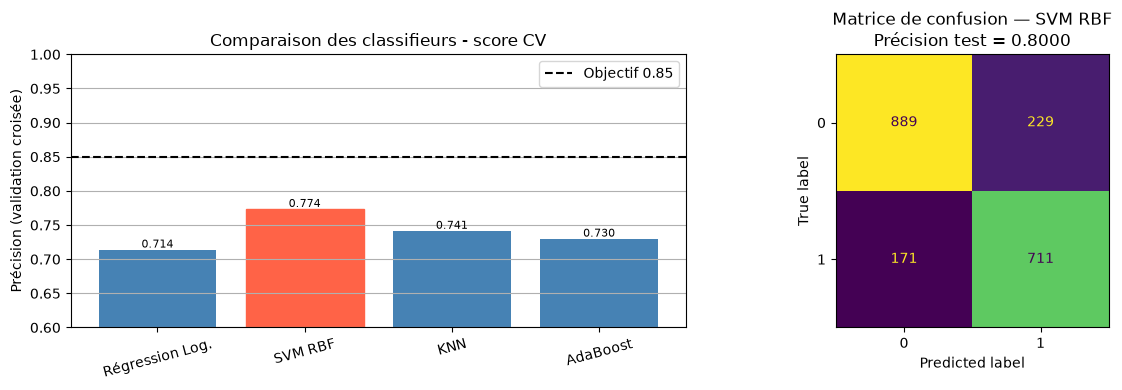

In [9]:
# Comparaison des scores CV uniquement
names    = list(results.keys())
cv_accs  = [v[1] for v in results.values()]
best_idx = names.index(best_name)

x = np.arange(len(names))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
bars = ax.bar(x, cv_accs, color=['steelblue']*len(names))
bars[best_idx].set_color('tomato')
ax.axhline(0.85, color='k', ls='--', lw=1.5, label='Objectif 0.85')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15)
ax.set_ylabel('Précision (validation croisée)')
ax.set_title('Comparaison des classifieurs - score CV')
ax.set_ylim([0.6, 1.0])
ax.legend(); ax.grid(axis='y')
for bar, cv in zip(bars, cv_accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{cv:.3f}', ha='center', fontsize=8)

# Matrice de confusion du meilleur modèle
y_pred_best = best_model.predict(X_test_s)
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[1], colorbar=False)
axes[1].set_title(
    f'Matrice de confusion — {best_name}\n'
    f'Précision test = {final_test_acc:.4f}'
)

plt.tight_layout()
plt.show()

## Conclusion

**Méthodologie :** chaque modèle est optimisé par validation croisée stratifiée à 5 plis sur l'ensemble d'entraînement uniquement. Le modèle final est sélectionné par son score CV, puis évalué une seule fois sur l'ensemble de test pour obtenir une estimation non biaisée de la précision de généralisation.

**Résultats :**
- Le **SVM à noyau RBF** obtient le meilleur score CV (0.774) et est sélectionné comme modèle final avec une précision test de **80.0 %**.
- KNN (CV = 0.742) et la régression logistique (CV = 0.714) suivent, mais restent nettement derrière le SVM.
- AdaBoost (CV = 0.730) montre des limites sur ce type de données.

**Interprétation :** la supériorité du SVM avec noyau RBF indique que les frontières de décision sont **non linéaires**. Le dataset présente 10 features à haute variance fortement corrélées, ce qui suggère que le signal utile réside dans un sous-espace de faible dimension bien adapté aux méthodes à noyau. La précision test (80 %) est stable par rapport au score CV (77 %), ce qui confirme une bonne généralisation sans surapprentissage.

L'erreur résiduelle (~20 %) reflète probablement une erreur de Bayes intrinsèque du dataset, indépendante du choix du modèle.